# EDA for card fraud detection

The purpose is to find vulnerabilities and explore the dataset

In [101]:
# import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [102]:
df.shape

(7043, 21)

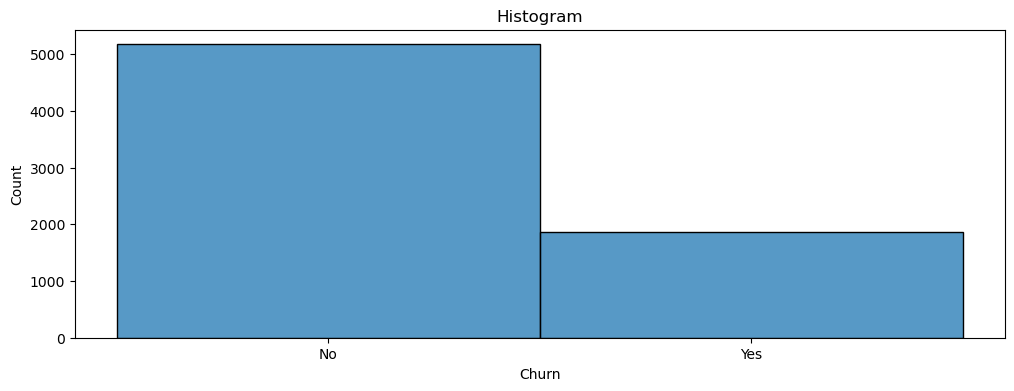

In [103]:
# histogram
plt.figure(figsize=(12, 4))
sns.histplot(df["Churn"])
plt.title("Histogram")
plt.show()

In [104]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [105]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

customerID: 7043
gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
tenure: 73
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
MonthlyCharges: 1585
TotalCharges: 6531
Churn: 2


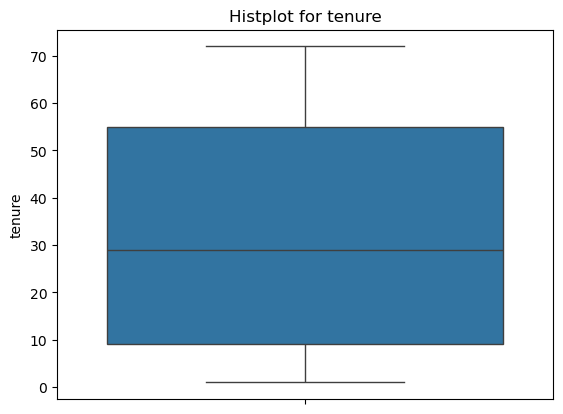

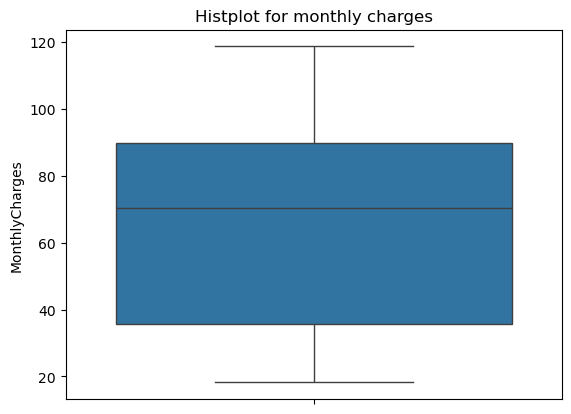

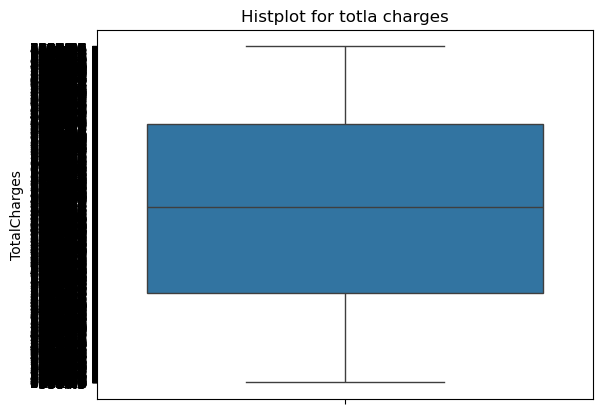

In [126]:
# checking values that make no sense
sns.boxplot(df["tenure"])
plt.title("Histplot for tenure")
plt.show()
sns.boxplot(df["MonthlyCharges"])
plt.title("Histplot for monthly charges")
plt.show()
sns.boxplot(df["TotalCharges"])
plt.title("Histplot for totla charges")
plt.show()

# Conclusion of histplots
No outliers can be seen

In [106]:
# dropping customer id since it makes no sense
df.drop(columns=["customerID"], inplace=True)

# encoding yes/no columns
yn = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in yn:
    df[col] = df[col].map({"Yes": 1, "No": 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [107]:
# encoding 
other = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["MultipleLines"] = df["MultipleLines"].map({"Yes": 2, "No": 1, "No phone service": 0})
df["InternetService"] = df["InternetService"].map({"DSL": 2, "Fiber optic": 1, "No": 0})
for col in other:
    df[col] = df[col].map({"Yes": 2, "No": 1, "No internet service": 0})
df["Contract"] = df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
df["PaymentMethod"] = df["PaymentMethod"].map({"Electronic check": 0, "Mailed check": 1, "Bank transfer (automatic)": 2, "Credit card (automatic)": 3})
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df.head(25)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,2,1,2,1,1,1,1,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,1,2,2,1,2,1,1,1,1,0,1,56.95,1889.5,0
2,1,0,0,0,2,1,1,2,2,2,1,1,1,1,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,2,2,1,2,2,1,1,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,1,1,1,1,1,1,1,1,0,1,0,70.70,151.65,1
5,0,0,0,0,8,1,2,1,1,1,2,1,2,2,0,1,0,99.65,820.5,1
6,1,0,0,1,22,1,2,1,1,2,1,1,2,1,0,1,3,89.10,1949.4,0
7,0,0,0,0,10,0,0,2,2,1,1,1,1,1,0,0,1,29.75,301.9,0
8,0,0,1,0,28,1,2,1,1,1,2,2,2,2,0,1,0,104.80,3046.05,1
9,1,0,0,1,62,1,1,2,2,2,1,1,1,1,1,0,2,56.15,3487.95,0


In [115]:
# remove white space
for col in df.columns:
    df = df[df[col].astype(str).str.strip() != ""]

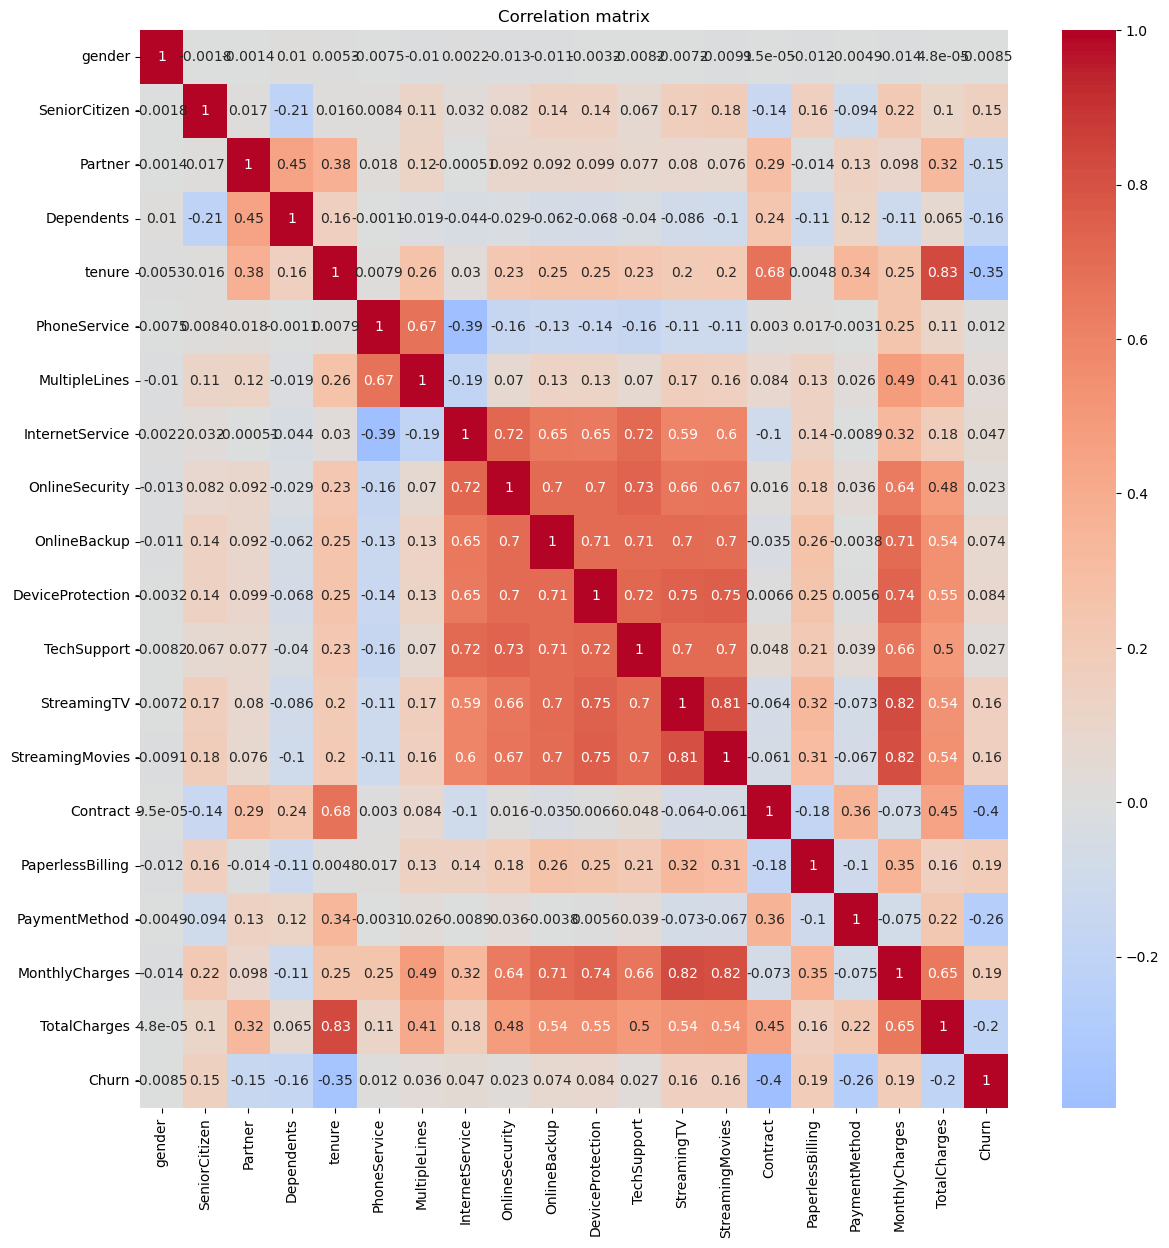

In [118]:
corr = df.corr()
plt.figure(figsize=(14, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation matrix")
plt.show()

# Conclusion of heatmap
The dataset looks good for training now.
The heatmaps shows that tenure and contract are the most influential columns on the target (churn). Also columns such as PaymentMethod, TotalCharges, PaperlessBilling, MonthlyCharges present a correlation with the churn column.